# 10. 训练稳定性与正则化技巧

深度学习中很多“模型效果不好”的问题，本质上不是模型结构不够强，而是训练不稳定：

- 梯度爆炸 / 梯度消失
- 参数初始化不合理
- 学习率不合适
- 过拟合
- 归一化与正则化缺失

这一节把这些工程上极其关键的细节系统化。

## 先建立直觉

            很多时候，模型学不好不是因为“模型不够先进”，而是因为训练过程本身不稳定。

你可以把训练想成在山谷里下山：

- 初始化决定你从哪里出发
- 学习率决定你步子迈多大
- 归一化决定地面是否平整
- 正则化决定你会不会为了贴合训练集而走偏

所以这节内容虽然不花哨，但是真正决定工程成败。

## 架构是怎么工作的

            这里讲的不是一个单独模型，而是任何深度网络都会用到的训练组件：

- 初始化
- 归一化
- Dropout
- Weight Decay
- Gradient Clipping
- Learning Rate Scheduler

它们共同组成了“训练稳定性工具箱”。

## 训练时到底发生了什么

            训练稳定性问题通常有几个典型症状：

- 损失一开始就爆炸
- 损失下降极慢
- 训练集很好但测试集很差
- 梯度非常大或非常小

解决这类问题时，优秀工程师往往不是盲目换模型，而是先排查：

1. 初始化是否合理
2. 学习率是否合理
3. 归一化是否缺失
4. 是否需要正则化

## 什么时候该用它

            实践建议非常直接：

- ReLU 网络优先 He 初始化
- 深层网络优先加 Norm
- 易过拟合任务优先考虑 Dropout / Weight Decay
- 序列模型优先加 Gradient Clipping
- 学习率不确定时，先从更小值开始

## 最常见的误区

            常见误区：

1. **误以为正则化越强越好**
   太强会让模型根本学不动。

2. **误以为 BatchNorm 只是“做标准化”**
   它还会改变优化动力学，提高训练稳定性。

3. **误以为训练不稳定就一定是代码 bug**
   很多时候只是初始化、学习率、归一化配置不合理。

## 1. 参数初始化

设线性层为 $y = Wx$。

如果初始化尺度过大，激活值和梯度会逐层放大；
如果尺度过小，激活值和梯度会逐层衰减。

常见初始化：

- Xavier / Glorot：适合 `tanh` 等对称激活
  $$
  \mathrm{Var}(W) \approx \frac{2}{n_{\mathrm{in}} + n_{\mathrm{out}}}
  $$
- He Initialization：适合 `ReLU`
  $$
  \mathrm{Var}(W) \approx \frac{2}{n_{\mathrm{in}}}
  $$

## 2. 归一化与正则化

### BatchNorm

$$
\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}},\qquad
y = \gamma \hat{x} + \beta
$$

### LayerNorm

LayerNorm 不是在 batch 维度上统计，而是在特征维度上统计，因此在 Transformer 中非常常见。

### Dropout

Dropout 会随机把部分神经元置零：

$$
\tilde{h} = m \odot h,\qquad m_i \sim \mathrm{Bernoulli}(1-p)
$$

### Weight Decay

通过约束权重大小抑制过拟合。

### Gradient Clipping

当梯度范数过大时，进行裁剪：

$$
g \leftarrow g \cdot \min\left(1,\frac{\tau}{\|g\|}\right)
$$

In [1]:
# 兼容当前 Windows 环境：把临时目录固定到用户目录下的 ASCII 路径，
# 避免 scipy / sklearn 在中文工作目录下寻找临时文件时报错。
from pathlib import Path
import os
import warnings

temp_root = Path(os.environ.get("ML_DL_TMP", str(Path.home() / ".ml_dl_notebook_tmp")))
temp_root.mkdir(exist_ok=True)
os.environ["TMP"] = str(temp_root)
os.environ["TEMP"] = str(temp_root)

warnings.filterwarnings("ignore")

import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
random.seed(42)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)


print("临时目录:", temp_root)

临时目录: C:\Users\41424\.ml_dl_notebook_tmp


In [2]:
# 观察不同初始化方式下，多层 ReLU 网络的激活统计量。
class DeepProbeNet(nn.Module):
    def __init__(self, width=256, depth=8):
        super().__init__()
        layers = []
        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        activations = []
        for layer in self.net:
            x = layer(x)
            if isinstance(layer, nn.ReLU):
                activations.append(x.detach().std().item())
        return activations


def init_model(model, mode):
    for module in model.modules():
        if isinstance(module, nn.Linear):
            if mode == "small":
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
            elif mode == "xavier":
                nn.init.xavier_uniform_(module.weight)
            elif mode == "he":
                nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
            else:
                raise ValueError(mode)
            nn.init.zeros_(module.bias)


x = torch.randn(512, 256)
init_records = []
for init_name in ["small", "xavier", "he"]:
    probe = DeepProbeNet()
    init_model(probe, init_name)
    stds = probe(x)
    for layer_id, std in enumerate(stds, start=1):
        init_records.append({"初始化": init_name, "层": layer_id, "激活标准差": std})

init_df = pd.DataFrame(init_records)

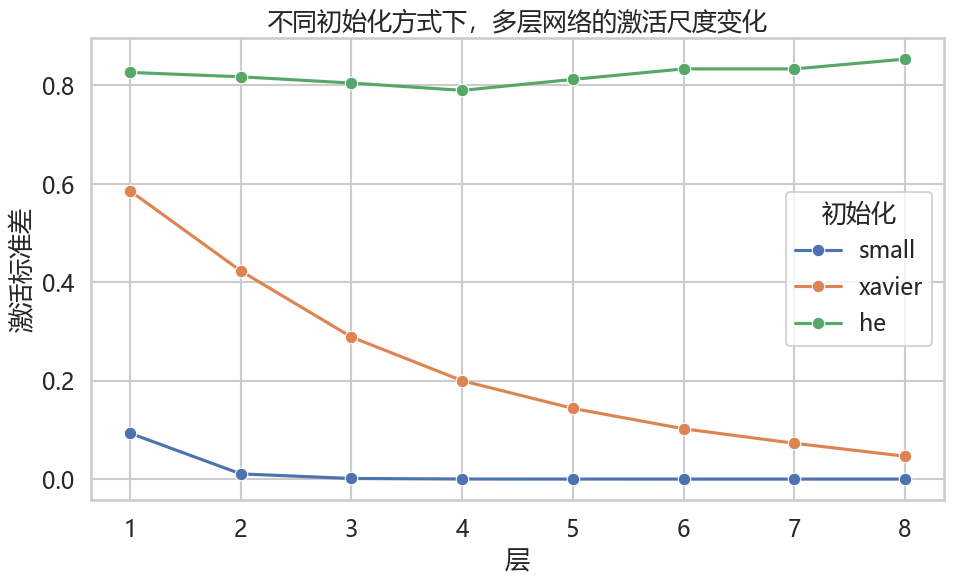

In [3]:
plt.figure(figsize=(11, 6))
sns.lineplot(data=init_df, x="层", y="激活标准差", hue="初始化", marker="o")
plt.title("不同初始化方式下，多层网络的激活尺度变化")
plt.show()

In [ ]:
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32)).astype(np.float32)
y = digits.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=64,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=256,
    shuffle=False,
)


class PlainMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


class StableMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


def train_regularized_model(model, weight_decay=0.0, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "test_acc": [], "lr": []}

    for _ in range(epochs):
        model.train()
        total_loss, total_count = 0.0, 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch_x.size(0)
            total_count += batch_x.size(0)

        model.eval()
        preds = []
        with torch.no_grad():
            for batch_x, _ in test_loader:
                preds.append(model(batch_x).argmax(dim=1))
        preds = torch.cat(preds).numpy()

        history["train_loss"].append(total_loss / total_count)
        history["test_acc"].append(accuracy_score(y_test, preds))
        history["lr"].append(optimizer.param_groups[0]["lr"])
        scheduler.step()

    return history

In [ ]:
regularization_setups = {
    "PlainMLP": (PlainMLP(), 0.0),
    "StableMLP": (StableMLP(), 1e-2),
}

reg_histories = {}
for name, (model, wd) in regularization_setups.items():
    history = train_regularized_model(model, weight_decay=wd, epochs=20)
    reg_histories[name] = history
    print(name, "最终测试准确率:", round(history["test_acc"][-1], 4))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, history in reg_histories.items():
    axes[0].plot(history["train_loss"], label=name)
    axes[1].plot(history["test_acc"], label=name)
    axes[2].plot(history["lr"], label=name)

axes[0].set_title("训练损失")
axes[1].set_title("测试准确率")
axes[2].set_title("学习率调度曲线")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 梯度裁剪的直观示例：同一个梯度，在裁剪前后范数如何变化。
toy_model = nn.Sequential(nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, 1))
toy_x = torch.randn(128, 16)
toy_y = 20 * torch.randn(128, 1)

pred = toy_model(toy_x)
loss = ((pred - toy_y) ** 2).mean() * 50
loss.backward()

before_clip = torch.sqrt(
    sum((param.grad.detach() ** 2).sum() for param in toy_model.parameters())
).item()

nn.utils.clip_grad_norm_(toy_model.parameters(), max_norm=1.0)

after_clip = torch.sqrt(
    sum((param.grad.detach() ** 2).sum() for param in toy_model.parameters())
).item()

print("裁剪前梯度范数:", round(before_clip, 4))
print("裁剪后梯度范数:", round(after_clip, 4))

## 3. 实战建议

- `ReLU` 网络优先尝试 He 初始化。
- CNN 中常见 `BatchNorm`，Transformer 中更常见 `LayerNorm` / `RMSNorm`。
- 如果训练集精度很高、测试集明显偏低，优先考虑 Dropout / Weight Decay / 数据增强。
- 如果训练一开始就震荡或发散，先降学习率，再检查初始化和归一化。
- 对 RNN / LLM 长序列训练，梯度裁剪通常是必需项。